# 10 · Google Colab: test larger LLMs on the SwasthyaSetu pipeline

**Goal:** run the *same* corrective pipeline from notebook 08 (spelling fix → search → evidence evaluator S/P/I/M → refine / re-retrieve / reject) with several LLMs on a Colab GPU, and see which model answers best.

**Fair test:** retrieval and the evidence labels are computed **once per question**; every model gets the **exact same prompt**. Only the LLM changes.

**Questions (≈ 90):**
- **A** — your 21 answer-test questions (`answer_questions.csv`)
- **B** — 22 *new* questions (10.7): new facts, lists, a table, a letter, case studies, a typo question, a scenario, and 5 that must be refused
- **N** — the 47 fair negatives (`negatives_50.csv`), which must all be refused

**Run order:** Step 0 once on your laptop → then 10.0 … 10.12 here (Runtime → Change runtime type → **T4 GPU**).

## Step 0 — on your laptop (once): pack the files Colab needs

Colab cannot see `D:\SwasthyaSetu`. Run this in a **local** notebook (e.g. notebook 08, laptop kernel). It creates `colab_bundle.zip` in the project root with `src/*.py`, `chunks.jsonl` and the two eval CSVs — no models, no `.env`.

```python
import zipfile
from pathlib import Path
ROOT = Path.cwd().parent                       # notebooks/ -> project root
files = sorted((ROOT / "src").glob("*.py")) + [ROOT / p for p in [
    "data/interim/chunks.jsonl", "data/eval/answer_questions.csv", "data/eval/negatives_50.csv"]]
with zipfile.ZipFile(ROOT / "colab_bundle.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for f in files:
        z.write(f, f.relative_to(ROOT).as_posix())
print("zipped:", [f.relative_to(ROOT).as_posix() for f in files])
```

Then: upload `colab_bundle.zip` to Google Drive → **Share → Anyone with the link → Viewer** → copy the link.
The **FILE_ID** is the part between `/d/` and `/view`. (The guideline is a public document; you can switch the link off again after testing.)

## 10.0  Check the GPU (Runtime -> Change runtime type -> T4 GPU)

In [2]:
# 10.0  Check the GPU (Runtime -> Change runtime type -> T4 GPU)
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv

name, memory.total [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 0 MiB


## # 10.1  Get the project files from your Google Drive link (Step 0)

In [3]:
# 10.1  Get the project files from your Google Drive link (Step 0)
import os, sys, zipfile

import gdown

FILE_ID = "1Xyfd3XFp3uF66k7xbmVc3ZA4xps4pSKg"            # .../file/d/<FILE_ID>/view
PROJECT = "/content/SwasthyaSetu"

if not os.path.exists(f"{PROJECT}/src/retriever.py"):
    gdown.download(id=FILE_ID, output="/content/colab_bundle.zip", quiet=False)
    zipfile.ZipFile("/content/colab_bundle.zip").extractall(PROJECT)
os.chdir(PROJECT)
sys.path.insert(0, PROJECT)
print("src:", sorted(os.listdir("src")))
print("chunks.jsonl found:", os.path.exists("data/interim/chunks.jsonl"))

Downloading...
From: https://drive.google.com/uc?id=1Xyfd3XFp3uF66k7xbmVc3ZA4xps4pSKg
To: /content/colab_bundle.zip
100%|██████████| 136k/136k [00:00<00:00, 86.9MB/s]

src: ['__init__.py', 'answer.py', 'paths.py', 'profile_pdf.py', 'query.py', 'retriever.py', 'test_extract.py', 'text_utils.py']
chunks.jsonl found: True


## # 10.2  Packages Colab does not have (pandas, numpy, requests are already there)

In [4]:
# 10.2  Packages Colab does not have (pandas, numpy, requests are already there)
!pip -q install rank-bm25 snowballstemmer fastembed chromadb pyspellchecker

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 16.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.6/111.6 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.8/129.8 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 81.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 142.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 143.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 36.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━

##  10.3  Install Ollama and start its server in the background

In [6]:
# 10.3  Install Ollama and start its server in the background
!apt-get -qq install -y zstd pciutils > /dev/null
!curl -fsSL https://ollama.com/install.sh | sh > /dev/null
import subprocess, time, requests

OLLAMA = "http://localhost:11434"
server = subprocess.Popen(["ollama", "serve"], stdout=open("/content/ollama.log", "w"), stderr=subprocess.STDOUT)
for second in range(60):
    try:
        requests.get(f"{OLLAMA}/api/tags", timeout=2)
        print("Ollama is running")
        break
    except requests.ConnectionError:
        time.sleep(1)

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Ollama is running


# 10.4  Load our own code: retriever, spelling fixer, prompt (the same files as on the laptop)

In [7]:
# 10.4  Load our own code: retriever, spelling fixer, prompt (the same files as on the laptop)
import re, time
import pandas as pd
from src.retriever import Retriever, STOP
from src.query import SpellFixer
import src.answer as answer_mod

R = Retriever()                  # first run builds data/vectordb (~1-2 min) and downloads the small models
SP = SpellFixer(R.chunks)
NOT_FOUND = answer_mod.NOT_FOUND
print(len(R.chunks), "chunks |", R.search("Who should be on the interview panel?", k=1)[0]["chunk_id"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

466 chunks | S074-05


## 10.5    Evidence evaluator + action boxes (same logic as notebook 08: cells 08.17, 08.21, 08.22)

In [8]:
# 10.5  Evidence evaluator v2: label each retrieval S / P / I / M
LOWER, UPPER = -5.0, 0.0                       # best rerank < LOWER: I | LOWER..UPPER: ambiguous | >= UPPER: ok
NUMBER = r"(?<![a-z0-9])\d+(?:-\d+)?(?![a-z0-9])"

def norm(text):
    return re.sub(r"[\u2010-\u2015\u2212]", "-", str(text).lower())

def stems(text):
    return set(R.tokenize(norm(text)))

CORPUS_STEMS = {s for c in R.chunks for s in stems(c["embed_text"])}
PDF_NUMBERS = {n for c in R.chunks for n in re.findall(r"\d+(?:-\d+)?", norm(c["text"]))}

def strong_parts_v2(question):
    # (hard, soft, numbers): acronyms / non-English names are hard, capitalised English words are soft
    hard, soft = [], []
    for sentence in re.split(r"(?<=[.?!])\s+", question.strip()):
        for i, word in enumerate(re.findall(r"[A-Za-z][A-Za-z0-9]*", sentence)):
            acronym = word.isupper() and len(word) > 1
            if not acronym and (i == 0 or not word[0].isupper()):
                continue
            is_english = bool(SP.english.known([word.lower()]))
            (hard if acronym or not is_english else soft).append(word)
    return hard, soft, re.findall(NUMBER, norm(question))

def signals_from_hits(fixed, hits):
    evidence = " ".join(h["path"] + " " + h["text"] for h in hits)
    evidence_stems, evidence_numbers = stems(evidence), set(re.findall(NUMBER, norm(evidence)))
    hard, soft, numbers = strong_parts_v2(fixed)

    def word_status(word):
        word_stems = stems(word)
        if not word_stems:
            return "ok"
        if not word_stems <= CORPUS_STEMS:
            return "out"
        return "ok" if word_stems <= evidence_stems else "missing"

    status = {w: word_status(w) for w in hard + soft}
    status.update({n: "ok" if n in evidence_numbers else ("missing" if n in PDF_NUMBERS else "out") for n in numbers})
    return {"best": round(max(h["score"] for h in hits), 2),
            "hard_out": [p for p in hard + numbers if status[p] == "out"],
            "soft_out": [p for p in soft if status[p] == "out"],
            "missing": [p for p in status if status[p] == "missing"]}

def predict_v2(sig):
    if sig["best"] < LOWER:
        return "I"
    if sig["hard_out"]:
        return "M"
    if sig["soft_out"] or sig["missing"] or sig["best"] < UPPER:
        return "P"
    return "S"

print(strong_parts_v2("We are planning a drive. What should HR confirm for Odisha's P4P model in 2024-25?"))

(['HR', 'Odisha', 'P4P'], [], ['2024-25'])


## 10.6  Action boxes: RE-RETRIEVE (P), REFINE (S/P), notes for P, REJECT / SCOPED (I / M)

In [9]:
# 10.6  Action boxes: RE-RETRIEVE (P), REFINE (S/P), notes for P, REJECT / SCOPED (I / M)
REFINE = True          # set False to send whole chunks (to test whether refine helps or hurts)
KEEP_STRIPS = 2
POOL = 10

def re_retrieve(fixed, sig, k=5):
    keywords = " ".join(w for w in re.findall(r"[A-Za-z0-9][A-Za-z0-9-]*", fixed) if w.lower() not in STOP)
    queries = [fixed, keywords] + ([" ".join(sig["missing"]) + " " + keywords] if sig["missing"] else [])
    pool = list({h["chunk_id"]: h for q in queries for h in R.search(q, k=POOL)}.values())
    scores = R.reranker.rerank(fixed, [R.chunks[R.row_of[h["chunk_id"]]]["embed_text"] for h in pool])
    for hit, score in zip(pool, scores):
        hit["score"] = float(score)
    return sorted(pool, key=lambda h: -h["score"])[:k]

def refine(hits, question):
    for hit in hits:
        sentences = [s.strip() for s in re.split(r"(?<=[.;?])\s+|\n+", hit["text"]) if s.strip()]
        if hit["doc_type"] == "table" or len(sentences) <= 2 * KEEP_STRIPS + 1:
            continue
        scores = list(R.reranker.rerank(question, sentences))
        top = sorted(range(len(sentences)), key=lambda i: -scores[i])[:KEEP_STRIPS]
        chosen = sorted({j for i in top for j in (i - 1, i, i + 1) if 0 <= j < len(sentences)})
        hit["text"] = " ".join(("… " if n and j != chosen[n - 1] + 1 else "") + sentences[j] for n, j in enumerate(chosen))
    return hits

def notes_for(sig):
    notes = []
    if sig["soft_out"]:
        notes.append(f"The sources do not mention {', '.join(sig['soft_out'])}. Say that the guideline does not cover it; "
                     f"answer only for NHM if the sources clearly cover that.")
    if sig["missing"]:
        notes.append(f"The sources may not contain: {', '.join(sig['missing'])}.")
    if sig["best"] < UPPER:
        notes.append(f"The evidence is weak. If the sources do not clearly answer the question, reply exactly: {NOT_FOUND}")
    return notes

def prepare(question):
    # Everything except the LLM call: done ONCE per question, so every model gets the same prompt
    fixed, changes = SP.fix(question)
    hits = R.search(fixed, k=5)
    sig = signals_from_hits(fixed, hits)
    first = final = predict_v2(sig)
    if first == "P":
        hits = re_retrieve(fixed, sig)
        sig = signals_from_hits(fixed, hits)
        final = predict_v2(sig)
    base = {"fixed": fixed, "first": first, "final": final, "best": sig["best"]}
    if final == "I":
        return {**base, "action": "reject", "fixed_answer": NOT_FOUND, "prompt": "", "notes": ""}
    if final == "M":
        terms = ", ".join(sig["hard_out"])
        scoped = f"The guideline does not cover {terms}. It covers human resources under the National Health Mission (NHM) only."
        return {**base, "action": "scoped", "fixed_answer": scoped, "prompt": "", "notes": ""}
    notes = notes_for(sig) if final == "P" else []
    hits = answer_mod.add_context(hits, R)
    hits = refine(hits, fixed) if REFINE else hits
    prompt = ("Important: " + " ".join(notes) + "\n\n" if notes else "") + answer_mod.build_prompt(fixed, hits)
    return {**base, "action": "answer_with_note" if notes else "answer", "fixed_answer": "", "prompt": prompt,
            "notes": " | ".join(notes)}

## 10.7 Questions

In [10]:
# 10.7  22 NEW questions (B). Answers checked against the guideline text (PDF page in the comment).
#       must_have: every '&&' group must match (regex, '|' = or) | must_not: no group may match
NEW_QUESTIONS = [
    # qid, kind, question, must_have, must_not, expected
    ("B01", "fact", "For how long does the waiting list stay valid after the result is declared?", "one year|1 year|12 months", "", "answer"),            # p36
    ("B02", "fact", "For at least how many days must a vacancy advertisement stay in the public domain?", "15 days|fifteen days", "", "answer"),         # p33
    ("B03", "list", "Besides name, designation and photograph, what must an NHM identity card show?", "blood group && emergency contact", "", "answer"),  # p38
    ("B04", "fact", "Within what period after joining should the orientation programme be held, and how long should it be?",
     "month && half a day|one day|1 day", "", "answer"),                                                                                               # p38
    ("B05", "fact", "How much notice does SHS/DHS have to give to terminate an appointment under the model contract?", "one month|1 month", "", "answer"),  # p76
    ("B06", "fact", "For what period can a State Health Society engage interns?", r"1\s*month|one month && 1 year|one year", "", "answer"),              # p29
    ("B07", "fact", "In the appraisal score, what weightage goes to the Work Performance Based Assessment indicators?", r"60\s*%", "", "answer"),         # p80
    ("B08", "fact", "Which committee must every workplace constitute under the 2013 sexual harassment Act?", "internal complaints? committee", "", "answer"),  # p49
    ("B09", "table-reason", "According to Exhibit 2, which selection stages are used for all three categories of staff?",
     "written && interview", "skill test && group discussion", "answer"),                                                                              # p34
    ("B10", "list", "What three aspects should the induction of a new employee cover?", "administrative && NHM && role|programme", "", "answer"),        # p38
    ("B11", "letter", "On what date was the letter on Experience Bonus for HR under NHM issued?", r"18(th)?\s*December,?\s*2018|December,?\s*2018", "", "answer"),  # p20
    ("B12", "case-study", "How much did oxytocin administration for AMTSL improve in Bihar's nurse mentoring programme?", r"8\.6 && 58\.5", "", "answer"),  # p165
    ("B13", "case-study", "What corpus fund was allocated for KBK and KBK plus districts in Odisha?", r"11\s*crore", "", "answer"),                     # p153
    ("B14", "case-study", "What incentive did specialist mentors get per FRU visit after the mentoring period in UP's buddy model?", "2,?500", "", "answer"),  # p167
    ("B15", "typo", "wat is the waitng list valdity after reslt is declard?", "one year|1 year|12 months", "", "answer"),                               # p36
    ("B16", "scenario", "My colleague lost her NHM ID card. What should she do?", "police", "", "answer"),                                             # p38
    ("B17", "fact", "To whom should a new employee be introduced on joining?", "team", "", "answer"),                                                  # p38
    # --- must be refused (not in the guideline) ---
    ("B18", "unanswerable", "Which software company developed the HRMIS used by all states?", "", "", "refuse"),
    ("B19", "unanswerable", "What is the salary of a staff nurse in Uttar Pradesh in 2025?", "", "", "refuse"),
    ("B20", "false-premise", "What is the probation period for Tata Steel employees?", "", "", "refuse"),
    ("B21", "false-premise", "How much notice must Navy officers give before resigning?", "", "", "refuse"),
    ("B22", "false-premise", "How many ASHAs will be recruited under NHM in 2030?", "", "", "refuse"),
]
new_df = pd.DataFrame(NEW_QUESTIONS, columns=["qid", "kind", "question", "must_have", "must_not", "expected"]).assign(set="B")
new_df.to_csv("data/eval/answer_questions_B.csv", index=False)

old_df = pd.read_csv("data/eval/answer_questions.csv").fillna("")
old_df["expected"] = old_df["kind"].map(lambda kind: "refuse" if kind == "unanswerable" else "answer")
old_df["set"] = "A"

neg = pd.read_csv("data/eval/negatives_50.csv")
neg = neg[~neg["marker_in_pdf"]].reset_index(drop=True)
neg_df = pd.DataFrame({"qid": [f"N{i:02d}" for i in range(1, len(neg) + 1)], "kind": neg["type"], "question": neg["question"],
                       "must_have": "", "must_not": "", "expected": "refuse", "set": "N"})

questions = pd.concat([old_df, new_df, neg_df], ignore_index=True).fillna("")
print(questions.groupby(["set", "expected"]).size().to_string())

set  expected
A    answer      18
     refuse       3
B    answer      17
     refuse       5
N    refuse      47


## 10.8

In [26]:
# 10.8  Retrieval + evidence labels + prompts, ONCE per question (no LLM yet, ~2-3 min)
prepared = pd.DataFrame([{**row, **prepare(row["question"])} for row in questions.to_dict("records")])
prepared["needs_llm"] = prepared["prompt"] != ""
print(pd.crosstab([prepared["set"], prepared["expected"]], prepared["final"]).to_string())
print(f"\nLLM calls per model: {prepared['needs_llm'].sum()} of {len(prepared)} questions")

final          I   M  P   S
set expected               
A   answer     0   0  0  18
    refuse     0   0  3   0
B   answer     0   0  1  16
    refuse     0   3  1   1
N   refuse    25  16  6   0

LLM calls per model: 46 of 90 questions


## Run the models

All models below fit a free **T4 (15 GB)** at the default 4-bit size. Remove models from the list if time is short.
Results are saved after **every model**, so a Colab disconnect does not lose finished models — re-run 10.9 and it skips them.

In [ ]:
# # 10.9  Pull each model, answer the SAME prompts, save after every model
# MODELS = ["llama3.2:3b",        # your laptop baseline
#           "phi4-mini",          # 3.8B
#           "qwen3:4b-instruct",  # 4B, the non-thinking Qwen3
#           "llama3.1:8b",
#           "qwen2.5:7b",
#           "qwen3:8b",           # hybrid: thinking switched off below
#           "gemma3:12b",
#           "qwen3:14b",          # hybrid: thinking switched off below
#           "phi4"]               # 14B
# THINK_OFF = {"qwen3:8b", "qwen3:14b"}
# RESULTS = "data/eval/colab_model_results.csv"

# def generate(model, prompt):
#     payload = {"model": model, "stream": False,
#                "messages": [{"role": "system", "content": answer_mod.SYSTEM_PROMPT}, {"role": "user", "content": prompt}],
#                "options": {"temperature": 0, "num_ctx": 4096, "num_predict": 512}}
#     if model in THINK_OFF:
#         payload["think"] = False
#     reply = requests.post(f"{OLLAMA}/api/chat", json=payload, timeout=900)
#     reply.raise_for_status()
#     return re.sub(r"<think>.*?</think>", "", reply.json()["message"]["content"], flags=re.S).strip()

# done = pd.read_csv(RESULTS) if os.path.exists(RESULTS) else pd.DataFrame(columns=["model"])
# for model in MODELS:
#     if model in set(done["model"]):
#         print(f"{model}: already done, skipped")
#         continue
#     pulled = subprocess.run(["ollama", "pull", model], capture_output=True, text=True)
#     if pulled.returncode != 0:
#         print(f"{model}: pull failed -> skipped | {pulled.stderr[-200:]}")
#         continue
#     generate(model, "Say OK")                          # warm-up: loads the model onto the GPU
#     rows, start = [], time.time()
#     for item in prepared.to_dict("records"):
#         t = time.time()
#         answer = generate(model, item["prompt"]) if item["needs_llm"] else item["fixed_answer"]
#         rows.append({"model": model, "qid": item["qid"], "set": item["set"], "kind": item["kind"], "question": item["question"],
#                      "expected": item["expected"], "must_have": item["must_have"], "must_not": item["must_not"],
#                      "first": item["first"], "final": item["final"], "action": item["action"], "notes": item["notes"],
#                      "needs_llm": item["needs_llm"], "answer": answer, "seconds": round(time.time() - t, 1)})
#     done = pd.concat([done, pd.DataFrame(rows)], ignore_index=True)
#     done.to_csv(RESULTS, index=False)
#     subprocess.run(["ollama", "stop", model], capture_output=True)
#     subprocess.run(["ollama", "rm", model], capture_output=True)   # frees disk for the next model
#     print(f"{model}: done in {(time.time() - start) / 60:.1f} min")

## Score the models

In [ ]:
# # 10.10  Score: answerable questions need the right content, the rest must be refused
# results = pd.read_csv(RESULTS).fillna("")

# def outcome_of(answer, action):
#     if answer.startswith(NOT_FOUND.rstrip(".")):
#         return "not_found"
#     if action == "scoped" or re.search(r"does not (cover|mention)|not covered", answer, re.I):
#         return "scoped"
#     return "answered"

# def is_correct(row):
#     if row["expected"] == "refuse":
#         return row["outcome"] in ("not_found", "scoped")
#     if row["outcome"] != "answered":
#         return False
#     have = [p.strip() for p in row["must_have"].split("&&") if p.strip()]
#     bad = [p.strip() for p in row["must_not"].split("&&") if p.strip()]
#     return all(re.search(p, row["answer"], re.I) for p in have) and not any(re.search(p, row["answer"], re.I) for p in bad)

# results["outcome"] = [outcome_of(a, act) for a, act in zip(results["answer"], results["action"])]
# results["correct"] = results.apply(is_correct, axis=1)
# results["cited"] = results["answer"].str.contains(r"\[\d", regex=True)

# answerable = results[results["expected"] == "answer"]
# refusable = results[results["expected"] == "refuse"]
# board = pd.DataFrame({
#     "answerable correct %": answerable.groupby("model")["correct"].mean() * 100,
#     "refused correctly %": refusable.groupby("model")["correct"].mean() * 100,
#     "wrong answers to refuse-questions": refusable.groupby("model")["outcome"].apply(lambda s: (s == "answered").sum()),
#     "citations % (answered)": answerable[answerable["outcome"] == "answered"].groupby("model")["cited"].mean() * 100,
#     "median s per LLM answer": results[results["needs_llm"]].groupby("model")["seconds"].median(),
# }).round(1).sort_values(["answerable correct %", "refused correctly %"], ascending=False)
# print(board.to_string())

In [ ]:
# # 10.11  Where each model wins or fails: by question kind, and the answerable questions it got wrong
# by_kind = answerable.pivot_table(index="kind", columns="model", values="correct", aggfunc="mean").mul(100).round(0)
# print("answerable correct % by kind:")
# print(by_kind[board.index].to_string())

# MODEL_TO_READ = board.index[0]                       # best model; change to read another one
# wrong = results[(results["model"] == MODEL_TO_READ) & ~results["correct"]]
# print(f"\n{MODEL_TO_READ}: {len(wrong)} wrong")
# for r in wrong.to_dict("records"):
#     print(f"\n[{r['qid']} {r['kind']} {r['first']}->{r['final']} {r['outcome']}] {r['question']}"
#           f"\n  expected: {r['expected']} | must_have: {r['must_have']} | must_not: {r['must_not']}"
#           f"\n  answer: {r['answer'][:350]}")

In [ ]:
# # 10.12  Keep the results: download the CSV (works in browser Colab; in VS Code copy the printed tables instead)
# try:
#     from google.colab import files
#     files.download(RESULTS)
# except Exception as error:
#     print("download not available here:", error)
#     print("file is at", os.path.abspath(RESULTS))

In [12]:
# 10.9  One model per cell; each answer is appended to its own CSV, so a timeout or disconnect loses nothing
import shutil
from pathlib import Path

THINK_OFF = {"qwen3:8b", "qwen3:14b"}
RESULTS_DIR = Path("data/eval/model_runs")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
KEEP = ["qid", "set", "kind", "question", "expected", "must_have", "must_not", "first", "final", "action", "notes", "needs_llm"]

def results_file(model):
    return RESULTS_DIR / f"{re.sub(r'[^a-z0-9]+', '-', model.lower())}.csv"

def generate(model, prompt, timeout=300, tries=2):
    payload = {"model": model, "stream": False,
               "messages": [{"role": "system", "content": answer_mod.SYSTEM_PROMPT}, {"role": "user", "content": prompt}],
               "options": {"temperature": 0, "num_ctx": 4096, "num_predict": 512}}
    if model in THINK_OFF:
        payload["think"] = False
    for attempt in range(1, tries + 1):
        try:
            reply = requests.post(f"{OLLAMA}/api/chat", json=payload, timeout=timeout)
            reply.raise_for_status()
            return re.sub(r"<think>.*?</think>", "", reply.json()["message"]["content"], flags=re.S).strip()
        except requests.RequestException as error:
            print(f"\n  {model} try {attempt}/{tries} failed: {type(error).__name__}")
    return "ERROR"

def run_model(model):
    path = results_file(model)
    saved = set(pd.read_csv(path)["qid"]) if path.exists() else set()
    todo = prepared[~prepared["qid"].isin(saved)]
    if todo.empty:
        print(f"{model}: all {len(saved)} answers already saved -> {path}")
        return
    pulled = subprocess.run(["ollama", "pull", model], capture_output=True, text=True)
    if pulled.returncode != 0:
        print(f"{model}: pull failed | {pulled.stderr[-200:]}")
        return
    generate(model, "Say OK")                                    # warm-up: loads the model onto the GPU
    start, failed = time.time(), []
    for number, item in enumerate(todo.to_dict("records"), 1):
        began = time.time()
        answer = generate(model, item["prompt"]) if item["needs_llm"] else item["fixed_answer"]
        if answer == "ERROR":
            failed.append(item["qid"])                           # not saved, so a re-run tries it again
            continue
        row = {"model": model, **{column: item[column] for column in KEEP}, "answer": answer, "seconds": round(time.time() - began, 1)}
        pd.DataFrame([row]).to_csv(path, mode="a", header=not path.exists(), index=False)
        print(f"\r{model}: {number}/{len(todo)}", end="")
    subprocess.run(["ollama", "stop", model], capture_output=True)
    print(f"\n{model}: {(time.time() - start) / 60:.1f} min -> {path} | failed: {failed or 'none'}")

## 10.9.1 Running llama3.2:3b

In [13]:
run_model("llama3.2:3b")

llama3.2:3b: 49/90
  llama3.2:3b try 1/2 failed: HTTPError
llama3.2:3b: 90/90
llama3.2:3b: 1.1 min -> data/eval/model_runs/llama3-2-3b.csv | failed: none


## 10.9.2 running phi4-mini

In [14]:
run_model("phi4-mini")

phi4-mini: 37/90
  phi4-mini try 1/2 failed: HTTPError
phi4-mini: 90/90
phi4-mini: 1.1 min -> data/eval/model_runs/phi4-mini.csv | failed: none


## 10.9.3 running qwen3:4b-instruct

In [15]:
run_model("qwen3:4b-instruct")

qwen3:4b-instruct: 33/90
  qwen3:4b-instruct try 1/2 failed: HTTPError
qwen3:4b-instruct: 90/90
qwen3:4b-instruct: 1.2 min -> data/eval/model_runs/qwen3-4b-instruct.csv | failed: none


## 10.9.4 running llama3.1:8b

In [16]:
run_model("llama3.1:8b")

llama3.1:8b: 37/90
  llama3.1:8b try 1/2 failed: HTTPError
llama3.1:8b: 90/90
llama3.1:8b: 2.3 min -> data/eval/model_runs/llama3-1-8b.csv | failed: none


## 10.9.5 Running qwen2.5:7b

In [17]:
run_model("qwen2.5:7b")

qwen2.5:7b: 90/90
qwen2.5:7b: 1.1 min -> data/eval/model_runs/qwen2-5-7b.csv | failed: none


## 10.9.6 running qwen3:8b

In [18]:
run_model("qwen3:8b")

qwen3:8b: 30/90
  qwen3:8b try 1/2 failed: HTTPError
qwen3:8b: 90/90
qwen3:8b: 2.2 min -> data/eval/model_runs/qwen3-8b.csv | failed: none


In [21]:
# 10.10  Load all model files and score them
results = pd.concat([pd.read_csv(path) for path in sorted(RESULTS_DIR.glob("*.csv"))], ignore_index=True).fillna("")

def outcome_of(answer, action):
    if answer.startswith(NOT_FOUND.rstrip(".")):
        return "not_found"
    if action == "scoped" or re.search(r"does not (cover|mention)|not covered", answer, re.I):
        return "scoped"
    return "answered"

def is_correct(row):
    if row["expected"] == "refuse":
        return row["outcome"] in ("not_found", "scoped")
    if row["outcome"] != "answered":
        return False
    have = [part.strip() for part in row["must_have"].split("&&") if part.strip()]
    bad = [part.strip() for part in row["must_not"].split("&&") if part.strip()]
    return all(re.search(part, row["answer"], re.I) for part in have) and not any(re.search(part, row["answer"], re.I) for part in bad)

results["outcome"] = [outcome_of(answer, action) for answer, action in zip(results["answer"], results["action"])]
results["correct"] = results.apply(is_correct, axis=1)
results["cited"] = results["answer"].str.contains(r"\[\d", regex=True)

answerable = results[results["expected"] == "answer"]
refusable = results[results["expected"] == "refuse"]
board = pd.DataFrame({
    "answers saved": results.groupby("model").size(),
    "answerable correct %": answerable.groupby("model")["correct"].mean() * 100,
    "refused correctly %": refusable.groupby("model")["correct"].mean() * 100,
    "wrong answers to refuse-questions": refusable.groupby("model")["outcome"].apply(lambda outcomes: (outcomes == "answered").sum()),
    "citations % (answered)": answerable[answerable["outcome"] == "answered"].groupby("model")["cited"].mean() * 100,
    "median s per LLM answer": results[results["needs_llm"].astype(bool)].groupby("model")["seconds"].median(),
}).round(1).sort_values(["answerable correct %", "refused correctly %"], ascending=False)
print(board.to_string())

                   answers saved  answerable correct %  refused correctly %  wrong answers to refuse-questions  citations % (answered)  median s per LLM answer
model                                                                                                                                                          
qwen2.5:7b                    90                  97.1                100.0                                  0                   100.0                      1.4
llama3.1:8b                   90                  94.3                100.0                                  0                   100.0                      1.8
qwen3:4b-instruct             90                  94.3                100.0                                  0                   100.0                      1.0
qwen3:8b                      90                  94.3                100.0                                  0                   100.0                      1.8
llama3.2:3b                   90        

In [ ]:
!pip install matplotlib

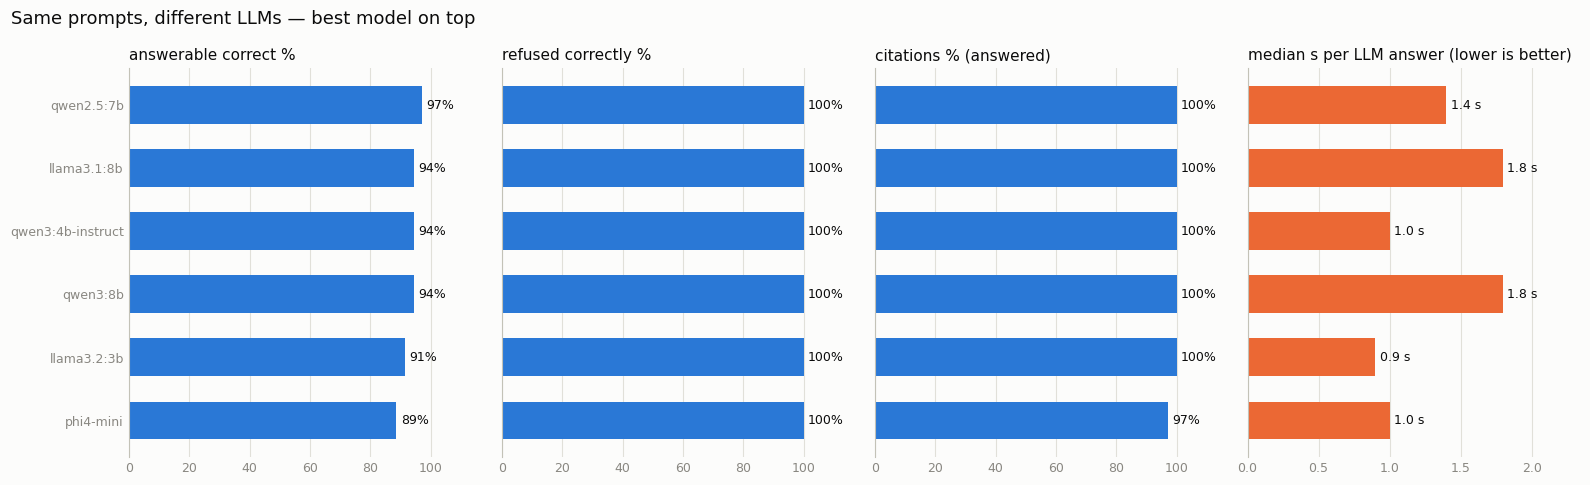

In [22]:
# 10.11  Comparison chart: one panel per measure, best model on top
import matplotlib.pyplot as plt

PANELS = [("answerable correct %", "#2a78d6", "%.0f%%"),
          ("refused correctly %", "#2a78d6", "%.0f%%"),
          ("citations % (answered)", "#2a78d6", "%.0f%%"),
          ("median s per LLM answer", "#eb6834", "%.1f s")]
order = board.index[::-1]
fig, axes = plt.subplots(1, len(PANELS), figsize=(16, 0.55 * len(board) + 1.6), sharey=True, facecolor="#fcfcfb")
for ax, (metric, colour, label) in zip(axes, PANELS):
    values = board.loc[order, metric].fillna(0)
    ax.bar_label(ax.barh(order, values, color=colour, height=0.6), fmt=label, padding=3, fontsize=9, color="#0b0b0b")
    ax.set_xlim(0, 110 if "%" in metric else values.max() * 1.3)
    ax.set_title(metric if "%" in metric else metric + " (lower is better)", loc="left", fontsize=11, color="#0b0b0b")
    ax.set_facecolor("#fcfcfb")
    ax.grid(axis="x", color="#e1e0d9")
    ax.set_axisbelow(True)
    ax.tick_params(colors="#898781", length=0, labelsize=9)
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.spines["left"].set_color("#c3c2b7")
fig.suptitle("Same prompts, different LLMs — best model on top", x=0.01, ha="left", fontsize=13, color="#0b0b0b")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "model_comparison.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

In [23]:
# 10.12  Where each model wins or fails
by_kind = answerable.pivot_table(index="kind", columns="model", values="correct", aggfunc="mean").mul(100).round(0)
print("answerable correct % by kind:")
print(by_kind[[model for model in board.index if model in by_kind.columns]].to_string())

MODEL_TO_READ = board.index[0]                       # best model; change to read another one
wrong = results[(results["model"] == MODEL_TO_READ) & ~results["correct"]]
print(f"\n{MODEL_TO_READ}: {len(wrong)} wrong")
for record in wrong.to_dict("records"):
    print(f"\n[{record['qid']} {record['kind']} {record['first']}->{record['final']} {record['outcome']}] {record['question']}"
          f"\n  expected: {record['expected']} | must_have: {record['must_have']} | must_not: {record['must_not']}"
          f"\n  answer: {record['answer'][:350]}")

answerable correct % by kind:
model         qwen2.5:7b  llama3.1:8b  qwen3:4b-instruct  qwen3:8b  llama3.2:3b  phi4-mini
kind                                                                                      
case-study         100.0        100.0              100.0     100.0        100.0      100.0
fact                95.0        100.0              100.0     100.0        100.0       90.0
letter             100.0        100.0              100.0     100.0        100.0      100.0
list               100.0         50.0               50.0      50.0         50.0       50.0
scenario           100.0        100.0              100.0     100.0          0.0      100.0
table              100.0        100.0              100.0     100.0        100.0      100.0
table-reason       100.0         50.0               50.0      50.0         50.0       50.0
typo               100.0        100.0              100.0     100.0        100.0      100.0

qwen2.5:7b: 1 wrong

[A11 fact S->S answered] Who should be

In [25]:
# 10.13  Download all model CSVs + chart as one zip (safe to run after any model)
archive = shutil.make_archive("/content/model_runs", "zip", RESULTS_DIR)
try:
    from google.colab import files
    files.download(archive)
except Exception as error:
    print("download not available here:", error, "| file is at", archive)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
print(generate(model='llama3.2:3b',prompt ="how long is the probation period for NHM staff?"))

The probation period for NHM staff is 6 months. [1]


In [31]:
print(generate(model='llama3.2:3b',prompt ="who should be on the interview panel of ipl"))

Not found in the guideline.


In [32]:
print(generate(model='llama3.2:3b',prompt ="When will a leaving ISRO scientist get the relieving letter"))

Not found in the guideline.


In [ ]:
MODELS = ["llama3.2:3b",        # your laptop baseline
          "phi4-mini",          # 3.8B
          "qwen3:4b-instruct",  # 4B, the non-thinking Qwen3
          "llama3.1:8b",
          "qwen2.5:7b",
          "qwen3:8b",           # hybrid: thinking switched off below
          "gemma3:12b",
          "qwen3:14b"]
for m in MODELS:
    print("model is-->{m}"generate(model=m,prompt="What is the probation period for contractual staff in the Army"))

Not found in the guideline.
Not found in the guideline.
Not found in the guideline.
Not found in the guideline.
Not found in the guideline.
Not found in the guideline.

  gemma3:12b try 1/2 failed: HTTPError

  gemma3:12b try 2/2 failed: HTTPError
ERROR

  qwen3:14b try 1/2 failed: HTTPError

  qwen3:14b try 2/2 failed: HTTPError
ERROR


In [37]:

print(generate(model="llama3.2:3b",prompt="Before we advertise a post, should the existing JD or ToR be reviewed??"))

According to the Guidelines on Human Resources for Health for NHM (2022), before advertising a post, the existing Job Description (JD) or Terms of Reference (ToR) should be reviewed to ensure it is accurate, complete, and relevant to the post being advertised [1].
